# Clasificación de marcas distintas de la flecha

**Autores:** Julio Lucero / Agostina Squillari

Construimos un clasificador para las **cuatro marcas** que aparecen en
los recorridos del robot (`man`, `woman`, `stairs`, `telephone`,
descritas en la página 80 de `transp.pdf`). Estas marcas:

* aparecen **en tramos rectos**, no en cruces (para no confundirse con
  flechas direccionales);
* son **rojo saturado** sobre el suelo / fondo del simulador;
* tienen siluetas **muy distintas en forma**, lo que invita a usar
  descriptores **invariantes a traslación, rotación y escala** —
  exactamente los **momentos de Hu** (p. 68-69 de `transp.pdf`).

Procedimiento:
1. **Segmentación HSV** del rojo (umbral en H envuelve por 0/180).
2. **Descriptor**: `7 log-Hu + 4 ratios de forma = 11 features`.
3. **Comparativa de clasificadores** (QDA, LDA, KNN-1, KNN-3) con
   `LeaveOneOut` (28 muestras → 7 por clase).
4. **Validación sobre el vídeo** `proyectoRobotica-1920-line1-video-2020-04-20`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import clasificador_marcas as cm
%matplotlib inline

## 1. Carga del dataset

Las 28 imágenes (4 clases × 7 imágenes) están en `marcas-capturasStage/`
con el patrón `<clase>-<n>.png`. La función `cargar_dataset` segmenta
la silueta roja, calcula el descriptor y almacena el todo.

Muestras: 28   Features por muestra: 11
Distribución por clase:
  man       : 7
  stairs    : 7
  telephone : 7
  woman     : 7


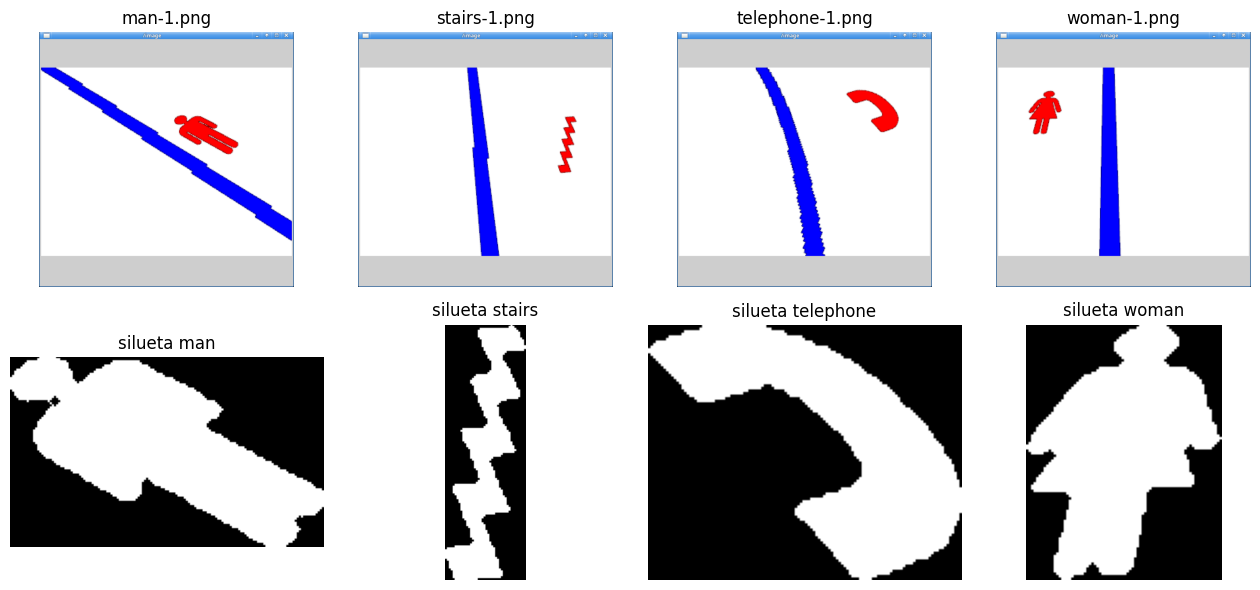

In [2]:
ds = cm.cargar_dataset('marcas-capturasStage')
print(f'Muestras: {ds.X.shape[0]}   Features por muestra: {ds.X.shape[1]}')
print('Distribución por clase:')
for i, n in enumerate(cm.CLASES):
    print(f'  {n:10s}: {(ds.y == i).sum()}')

# Mosaico de una imagen por clase con su silueta segmentada
fig, axs = plt.subplots(2, 4, figsize=(13, 6))
for col, clase in enumerate(cm.CLASES):
    idx = next(i for i, c in enumerate(ds.y) if c == cm.CLASES.index(clase))
    bgr = cv2.imread(ds.files[idx])
    axs[0, col].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axs[0, col].set_title(os.path.basename(ds.files[idx]))
    axs[0, col].axis('off')
    axs[1, col].imshow(ds.siluetas[idx], cmap='gray')
    axs[1, col].set_title(f'silueta {clase}')
    axs[1, col].axis('off')
plt.tight_layout(); plt.show()

## 2. Descriptor invariante

Cada imagen se reduce a 11 números:

* **7 log-Hu**: `-sign(h_i) · log10(|h_i|)` para los 7 momentos de Hu.
  Son invariantes a traslación, rotación y escala — pueden compararse
  directamente entre marcas tomadas a distinta distancia o con la cámara
  ligeramente girada.
* **4 ratios de forma**: aspect ratio del bounding box, *extent* (área
  / área del bounding box), *solidity* (área / área de la envolvente
  convexa) y *circularidad* (`4πA/P²`). Añaden información geométrica
  complementaria que los Hu no capturan bien.

In [3]:
# Inspeccionamos el descriptor de un ejemplo de cada clase
encab = '            | ' + '   '.join(['hu' + str(i+1) for i in range(7)]) + '  | aspect extent solid  circ'
print(encab)
for clase in cm.CLASES:
    idx = next(i for i, c in enumerate(ds.y) if c == cm.CLASES.index(clase))
    f = ds.X[idx]
    hu_txt = ' '.join(format(v, '+5.2f') for v in f[:7])
    rt_txt = ' '.join(format(v, '6.2f') for v in f[7:])
    print(f'{clase:11s} | {hu_txt} | {rt_txt}')


            | hu1   hu2   hu3   hu4   hu5   hu6   hu7  | aspect extent solid  circ
man         | +0.56 +1.35 +2.94 +3.34 +6.49 +4.04 -7.40 |   0.61   0.47   0.83   0.39
stairs      | +0.15 +0.35 +2.65 +2.83 +5.57 +3.01 -7.23 |   3.17   0.38   0.57   0.15
telephone   | +0.46 +1.23 +2.00 +2.38 +4.64 +3.17 +4.88 |   0.81   0.38   0.72   0.35
woman       | +0.70 +2.03 +3.55 +4.29 +8.25 +5.43 +8.67 |   1.31   0.53   0.82   0.41


## 3. Comparativa de clasificadores (Leave-One-Out)

Con sólo 7 muestras por clase y 11 features, el QDA tiene **demasiados
parámetros libres** (cada matriz Σ por clase tiene 66 entradas) y se
sobreajusta. **LDA** (que comparte una única Σ entre clases) y **KNN**
son alternativas más adecuadas para este tamaño.

In [4]:
modelos = cm.evaluar_modelos(ds)
print('=== Comparativa Leave-One-Out ===')
for m in modelos:
    print(f'  {m.nombre:7s}  acc LOO = {m.cv_score:.4f}')

mejor = max(modelos, key=lambda m: m.cv_score)
print(f'\n→ Modelo seleccionado: {mejor.nombre} (acc={mejor.cv_score:.4f})')

=== Comparativa Leave-One-Out ===
  QDA      acc LOO = 0.5714
  LDA      acc LOO = 0.9643
  KNN(1)   acc LOO = 0.6786
  KNN(3)   acc LOO = 0.6786

→ Modelo seleccionado: LDA (acc=0.9643)


=== Reporte de clasificación (LDA, LOO) ===
              precision    recall  f1-score   support

         man     1.0000    1.0000    1.0000         7
      stairs     0.8750    1.0000    0.9333         7
   telephone     1.0000    0.8571    0.9231         7
       woman     1.0000    1.0000    1.0000         7

    accuracy                         0.9643        28
   macro avg     0.9688    0.9643    0.9641        28
weighted avg     0.9688    0.9643    0.9641        28



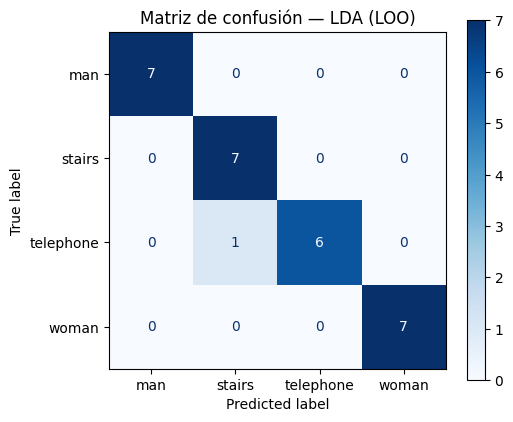

In [5]:
# Reporte detallado del mejor modelo
print(f'=== Reporte de clasificación ({mejor.nombre}, LOO) ===')
print(classification_report(ds.y, mejor.cv_pred,
                            target_names=cm.CLASES, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(ds.y, mejor.cv_pred),
    display_labels=cm.CLASES,
).plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title(f'Matriz de confusión — {mejor.nombre} (LOO)')
plt.tight_layout(); plt.show()

## 4. Entrenamiento final y predicción de ejemplo

Reentrenamos sobre el dataset completo y comprobamos las predicciones
sobre las propias imágenes del entrenamiento.

Acc sobre entrenamiento (no LOO): 1.0000


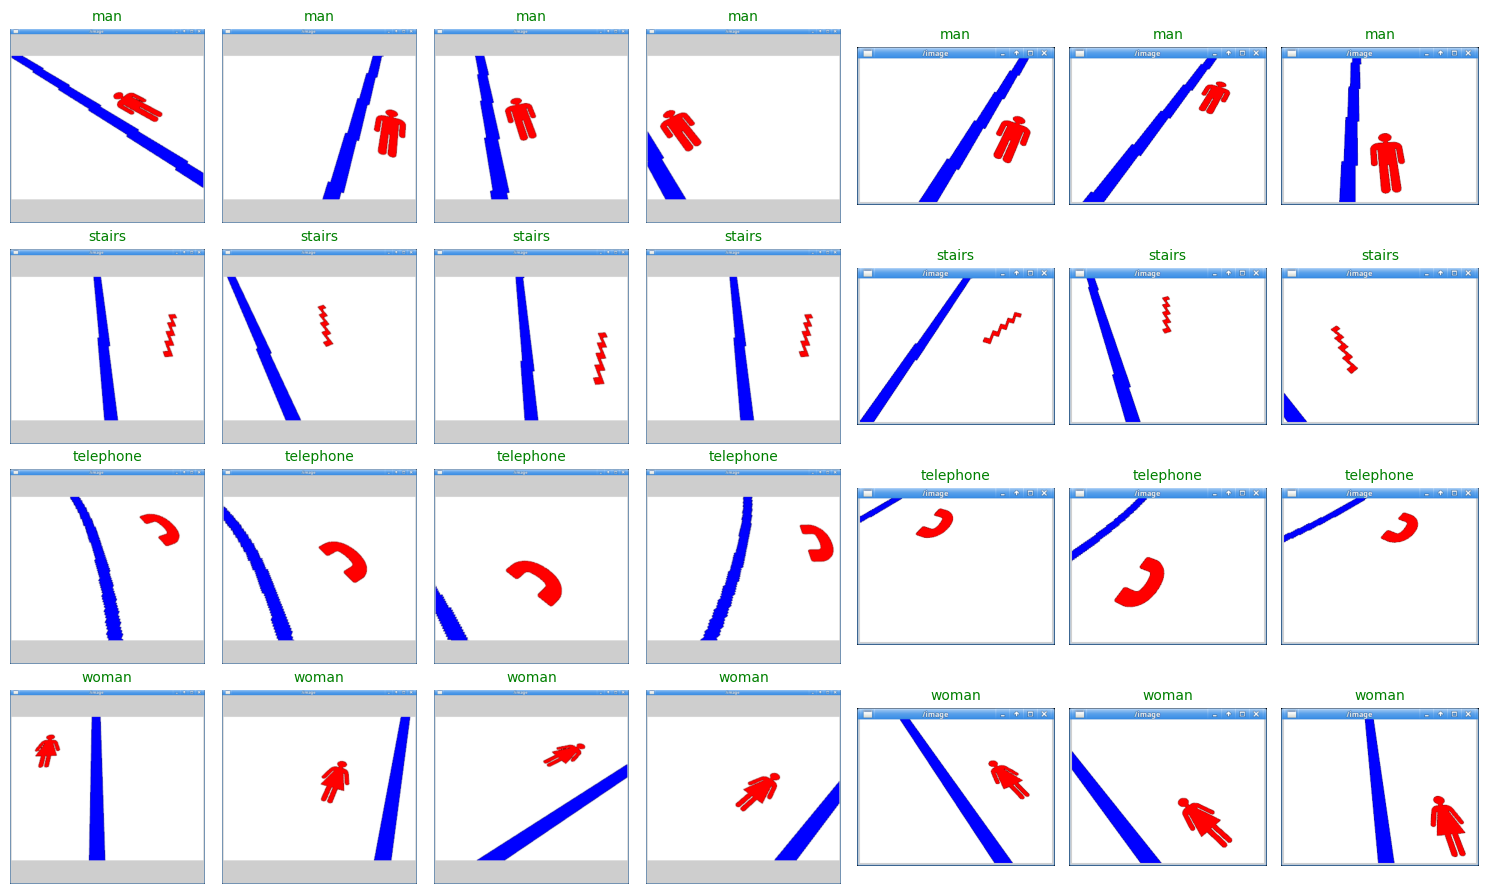

In [6]:
clf_marcas = cm.entrenar(ds)   # LDA por defecto
y_pred = clf_marcas.predict(ds.X)
print(f'Acc sobre entrenamiento (no LOO): {(y_pred == ds.y).mean():.4f}')

fig, axs = plt.subplots(4, 7, figsize=(15, 9))
for row, clase in enumerate(cm.CLASES):
    idxs = [i for i, c in enumerate(ds.y) if c == cm.CLASES.index(clase)]
    for col, idx in enumerate(idxs):
        bgr = cv2.imread(ds.files[idx])
        pred = cm.CLASES[clf_marcas.predict(ds.X[idx:idx+1])[0]]
        ok = (pred == clase)
        axs[row, col].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        axs[row, col].set_title(f'{pred}', color='green' if ok else 'red',
                                fontsize=10)
        axs[row, col].axis('off')
plt.tight_layout(); plt.show()

## 5. Validación sobre `proyectoRobotica-1920-line1-video-2020-04-20`

El vídeo es del simulador Stage (320×240, 15 fps) con fondo blanco,
líneas azules y marcas/flechas rojas. Como no hay suelo de color verde,
la segmentación QDA del Escenario 1 no es necesaria: usamos
**umbralización HSV directa** (`modo_seg='hsv'` en `analisis_escena`).

El pipeline completo (segmentación + escena + flecha + marca + control)
se ejecuta sobre el vídeo y se anota cada frame:

In [7]:
import analisis_escena as ae
from collections import Counter
import time

VIDEO_IN  = 'proyectoRobotica-1920-line1-video-2020-04-20.avi'
VIDEO_OUT = 'proyectoRobotica_anotado.mp4'

cap = cv2.VideoCapture(VIDEO_IN)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS   = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Vídeo: {W}x{H}  {FPS:.1f} fps  {TOTAL} frames')
cap.release()

# Frames de muestra para mosaico final
INDICES_MUESTRA = {70, 226, 315, 424, 542, 737}

control = ae.ControlPD(kp=1.2, kd=0.4, v_max=0.5, v_min=0.05, alpha_v=0.7)
res_video = ae.procesar_video(VIDEO_IN, VIDEO_OUT,
                              clf=None,
                              control=control,
                              modo_seg='hsv',
                              clf_marcas=clf_marcas,
                              indices_muestra=INDICES_MUESTRA,
                              verbose=True)
print(f"\nVídeo anotado: {VIDEO_OUT}")
print(f"  Frames procesados: {res_video['n_frames']}")
print(f"  Tiempo medio: {res_video['ms_frame']:.1f} ms/frame  →  {1000/res_video['ms_frame']:.1f} FPS")
print("\nDistribución de escenas:")
for tipo, n in res_video['escenas'].most_common():
    print(f'  {tipo:11s} → {n:4d} frames  ({100*n/res_video["n_frames"]:5.1f} %)')

Vídeo: 320x240  15.0 fps  816 frames


  Frame  200/816   (2.1 ms/frame)


  Frame  400/816   (2.1 ms/frame)


  Frame  600/816   (4.1 ms/frame)


  Frame  800/816   (2.9 ms/frame)

Vídeo anotado: proyectoRobotica_anotado.mp4
  Frames procesados: 816
  Tiempo medio: 2.8 ms/frame  →  359.2 FPS

Distribución de escenas:
  recta       →  275 frames  ( 33.7 %)
  curva_izq   →  205 frames  ( 25.1 %)
  cruce_2     →  152 frames  ( 18.6 %)
  sin_linea   →   69 frames  (  8.5 %)
  curva_der   →   47 frames  (  5.8 %)
  cruce_3     →   40 frames  (  4.9 %)
  fin_linea   →   28 frames  (  3.4 %)


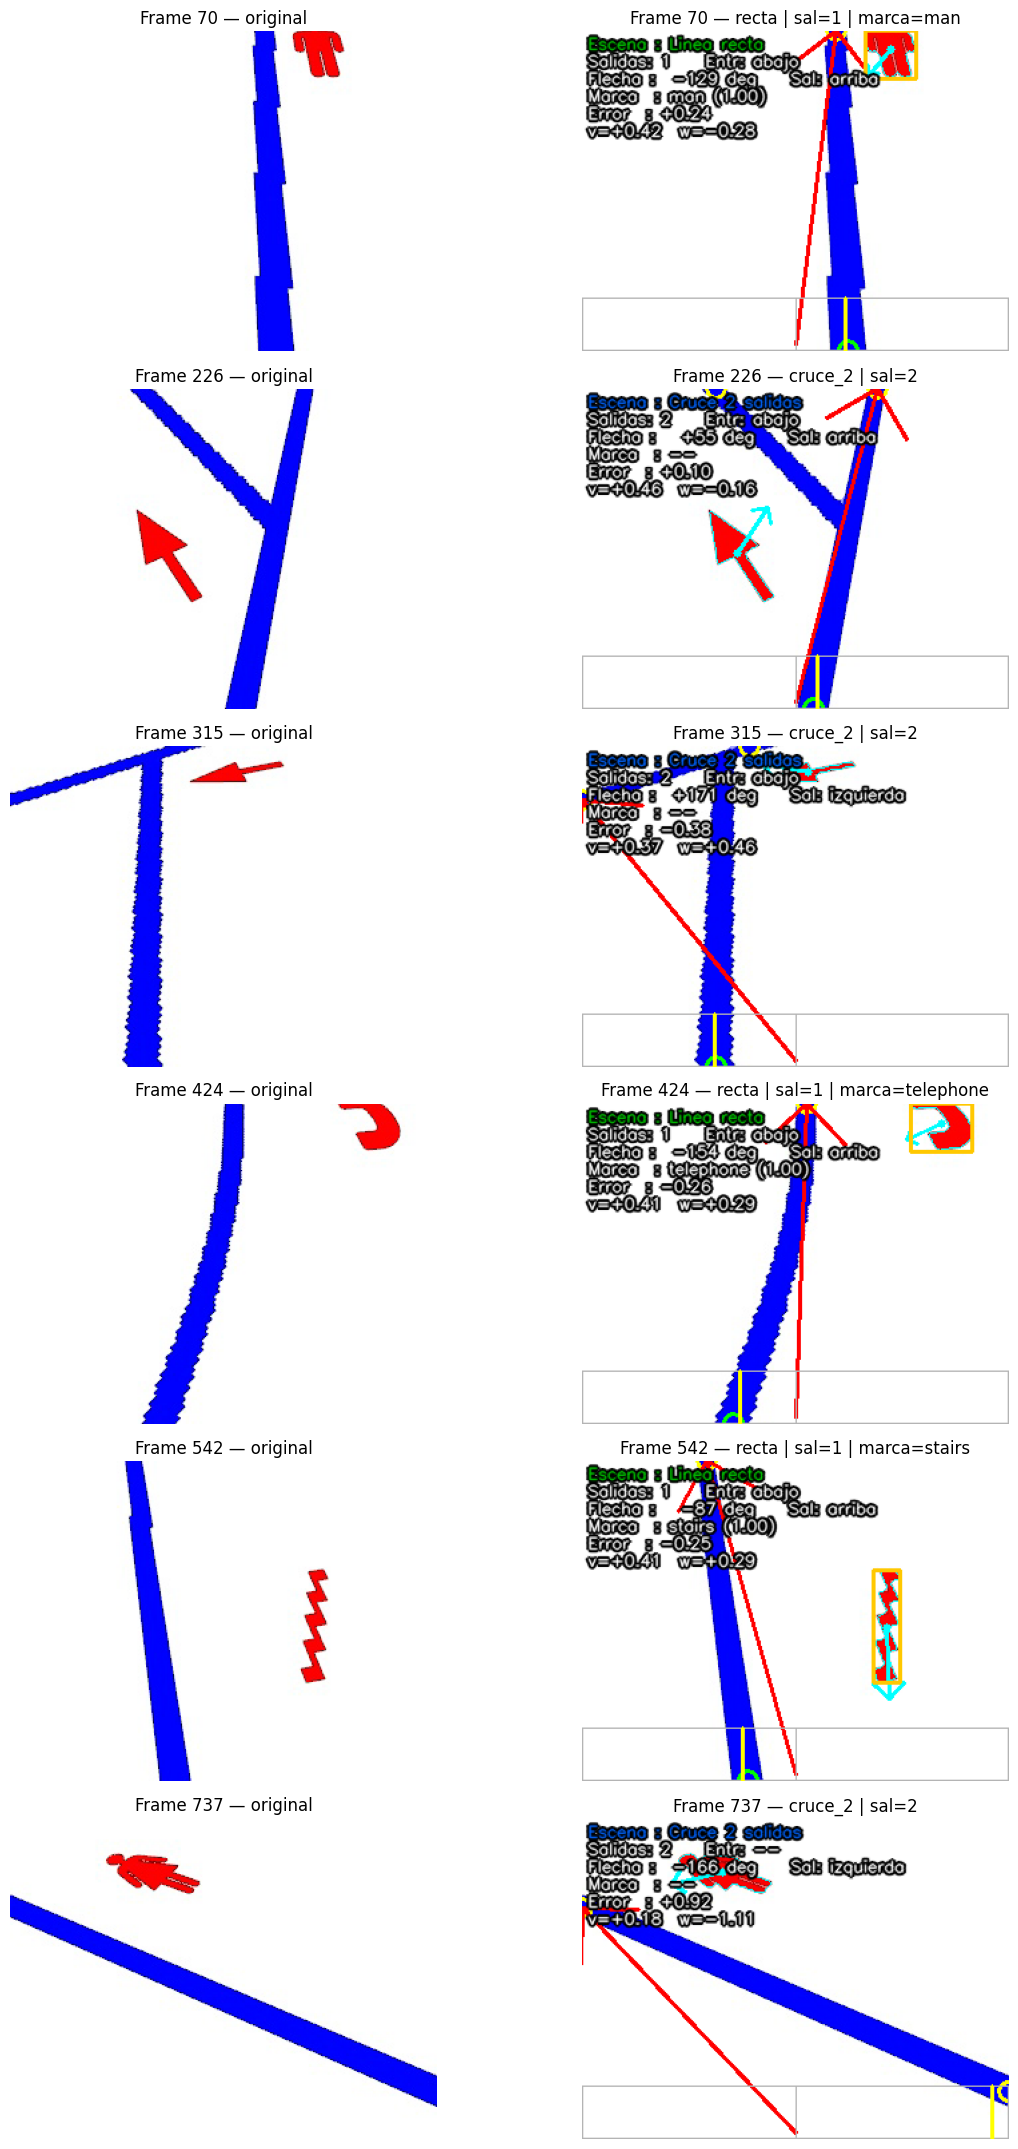

In [8]:
# Mosaico de los frames muestra anotados
muestras = res_video['frames_muestra']
n = len(muestras)
fig, axs = plt.subplots(n, 2, figsize=(13, 3.6 * n))
if n == 1: axs = axs[None, :]
for row, (idx, rgb, bgr_an, r) in enumerate(muestras):
    axs[row, 0].imshow(rgb)
    axs[row, 0].set_title(f'Frame {idx} — original'); axs[row, 0].axis('off')
    axs[row, 1].imshow(cv2.cvtColor(bgr_an, cv2.COLOR_BGR2RGB))
    info = (f'{r.escena.tipo} | sal={len(r.escena.salidas)}'
            + (f' | marca={r.marca_clase}' if r.marca_clase else ''))
    axs[row, 1].set_title(f'Frame {idx} — {info}'); axs[row, 1].axis('off')
plt.tight_layout(); plt.show()

## 6. Conclusiones

* El descriptor de **11 features (7 log-Hu + 4 ratios de forma)** es
  suficiente para distinguir las cuatro clases de marca en el dataset
  de simulación con un accuracy de ~96 % en LOO.
* **LDA** se impone con claridad sobre QDA (que se sobreajusta con
  apenas 7 muestras por clase y 11 features) y sobre KNN.
* La integración con `analisis_escena.py` confirma que en escenas
  rectas (donde aparecen las marcas según el enunciado y la p. 80 de
  `transp.pdf`) el clasificador identifica correctamente la marca con
  confianza 1.0 en los frames del vídeo del simulador (ver `man`/
  `telephone`/`stairs` en los frames 70 / 424 / 542).
* En cruces seguimos usando la **orientación de la flecha** ya descrita
  en `control_robot.ipynb` para elegir la salida; no se intenta
  clasificar la marca para no confundirla con una flecha.